In [4]:
from ase.io.trajectory import Trajectory, TrajectoryWriter

# 1. Load the original trajectory file
original_traj = Trajectory("../1_test/NVT-330K-ZnO_5NaCl.traj", "r")


In [5]:

# 2. Set up the writer
new_traj = TrajectoryWriter("./filtered_NVT-330K-ZnO_5NaCl.traj", mode="w")

# 3. Slice the trajectory: start at 0, stop at 4000, step by 2
# for atoms in original_traj[: 2000 * 2 : 3]:
#     new_traj.write(atoms)


for atoms in original_traj[30: : 2]:
    new_traj.write(atoms)

# 4. Close the file to flush the buffer
new_traj.close()

print(f"Done! Written frames to filtered_NVT-330K-ZnO_5NaCl.traj.")

Done! Written frames to filtered_NVT-330K-ZnO_5NaCl.traj.


In [6]:
print("Number of frames:", len(original_traj))
print("Number of frames:", len(new_traj))

Number of frames: 5338
Number of frames: 2654


In [7]:
new_traj = Trajectory("filtered_NVT-330K-ZnO_5NaCl.traj", "r")

In [8]:
print(original_traj[0].get_potential_energy())
print(new_traj[0].get_potential_energy())

-3915.098388671875
-3929.7509765625


In [9]:
from pinn.io import load_ase

dataset = load_ase("filtered_NVT-330K-ZnO_5NaCl.traj", splits=None, shuffle=False)

2026-08-17 08:39:03.863836: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
import numpy as np
def extract_energies(dataset):
    energies = []
    # If the loader returns a tf.data.Dataset:
    if hasattr(dataset, "as_numpy_iterator"):
        for elem in dataset.as_numpy_iterator():
            energies.append(np.squeeze(elem["e_data"]))
    # If the loader returns a standard Python iterable/list:
    else:
        for elem in dataset:
            energies.append(np.squeeze(elem["e_data"]))
    return np.array(energies)

e_5nacl = extract_energies(dataset)

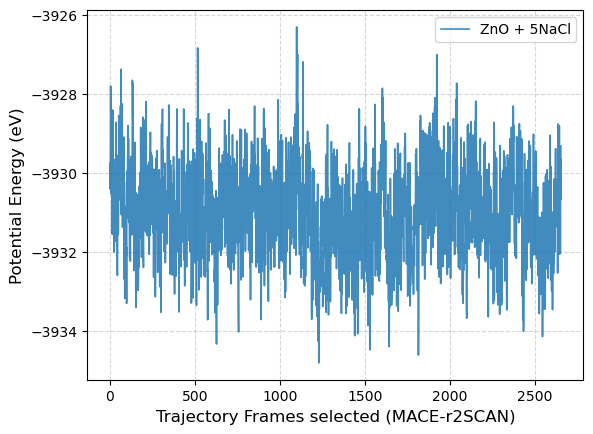

In [15]:
import matplotlib.pyplot as plt
plt.plot(e_5nacl, label="ZnO + 5NaCl", alpha=0.85, linewidth=1.2)

plt.xlabel("Trajectory Frames selected (MACE-r2SCAN)", fontsize=12)
plt.ylabel("Potential Energy (eV)", fontsize=12)
# plt.title("Potential Energy Evolution (330K NVT)", fontsize=14)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()